# Tutorial 7a: Feature Construction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
X=df[df.columns[1:-1]]
y=df[df.columns[-1]]

In [5]:
y.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=42, stratify=y)

In [7]:
X_train.head()

,sepal_width,petal_length,petal_width
29,3.2,1.6,0.2
145,3.0,5.2,2.3
8,2.9,1.4,0.2
148,3.4,5.4,2.3
25,3.0,1.6,0.2


# PCA

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_ss = scaler.transform(X_train)

### RUN PCA

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)   
pca.fit(X_train_ss)
pca_train = pca.transform(X_train_ss)
pca_train[:10,:]

array([[-1.7746517 , -0.44131222],
       [ 1.50937784,  0.55608894],
       [-1.57340709, -1.08745227],
       [ 1.21623277,  1.40808653],
       [-1.59085078, -0.8530273 ],
       [-1.80378947, -0.70406788],
       [ 1.67447261,  0.1162799 ],
       [-1.58149771, -0.83898032],
       [ 0.390896  , -0.21874981],
       [-1.71997963, -0.66145347]])

### Visualising the results

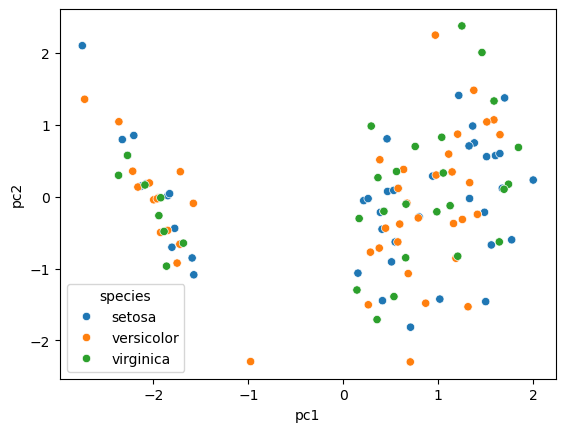

In [14]:
df_pca_train = pd.DataFrame(data = pca_train, columns = ['pc1', 'pc2'])
df_pca_train['species']=y_train
sns.scatterplot(x='pc1', y='pc2', hue=df_pca_train['species'], data=df_pca_train);

### Transform the test data

In [15]:
X_test_ss = scaler.transform(X_test)
pca_test = pca.transform(X_test_ss)

### Classification

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(random_state=0)
classifier.fit(X_train, y_train)
score = accuracy_score(classifier.predict(X_test), y_test)
print('Accuracy before transformation  = {:.2f}'.format(score))

Accuracy before transformation  = 0.93


In [17]:
classifier.fit(pca_train, y_train)
score = accuracy_score(classifier.predict(pca_test), y_test)
print('Accuracy after PCA transformation  = {:.2f}'.format(score))

Accuracy after PCA transformation  = 0.93


# ICA

In [18]:
from sklearn.decomposition import FastICA
ica = FastICA(n_components=2)
ica_train = ica.fit_transform(X_train_ss)

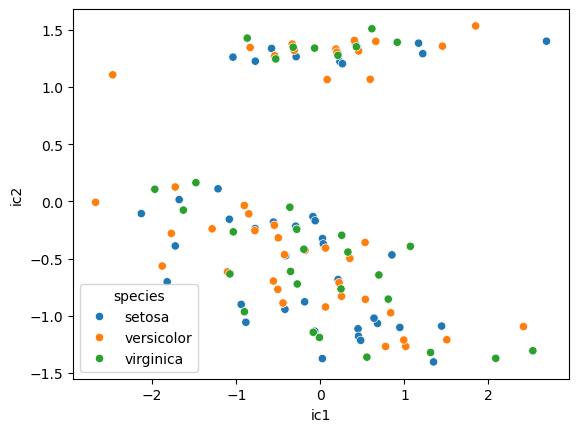

In [19]:
# Visualisation
df_ica_train = pd.DataFrame(data = ica_train, columns = ['ic1', 'ic2'])
df_ica_train['species']=y_train
sns.scatterplot(x='ic1', y='ic2', hue=df_ica_train['species'], data=df_ica_train);

In [20]:
classifier.fit(ica_train, y_train)
ica_test = ica.transform(X_test_ss)
score = accuracy_score(classifier.predict(ica_test), y_test)
print('Accuracy after ICA transformation  = {:.2f}'.format(score))

Accuracy after ICA transformation  = 0.93


### GP transformers

In [21]:
!pip install gplearn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 3.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.2 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 5.1 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 4.8 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 5.0 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.2 MB 4.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.5 MB/s  0:00:02

  Attempting uninstall: scikit-learn

    

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoded = le.fit_transform(y_train)
label_encoded

array([0, 2, 0, 2, 0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 2, 1, 2, 0, 0, 2, 0, 2, 0, 2, 2, 1, 0, 1, 0, 1, 1, 2, 1, 0,
       2, 2, 0, 1, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 2, 0, 2, 0, 1, 0, 1,
       1, 1, 2, 2, 2, 2, 1, 1, 0, 2, 1, 2, 1, 2, 1, 2, 0, 0, 0, 2, 1, 2,
       1, 1, 0, 1, 1, 0, 2, 1, 0, 2, 0, 2, 1, 1, 2, 0, 2, 1, 2, 0, 0, 2,
       2, 2, 1, 2, 1, 2, 0, 1, 0, 2, 2, 2, 0, 2, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0])

In [29]:
from gplearn.genetic import SymbolicTransformer
gp = SymbolicTransformer(n_components=2)
gp.fit(X_train_ss, label_encoded)
gp_train = gp.transform(X_train_ss)

<Axes: xlabel='gp1', ylabel='gp2'>

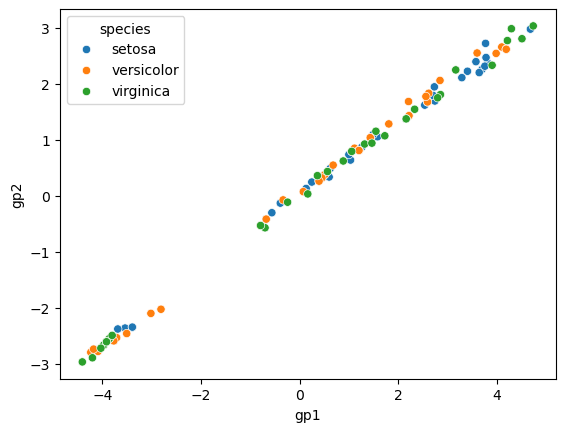

In [25]:
# Visualisation using the gp-based transformed data
df_gp_train = pd.DataFrame(data = gp_train, columns = ['gp1', 'gp2'])
df_gp_train['species']=y_train
sns.scatterplot(x='gp1', y='gp2', hue=df_gp_train['species'], data=df_gp_train)

In [26]:
# Transform test data using gp
# Then, performing classification using the ica-based transformed data
gp_test = gp.transform(X_test_ss)
df_gp_test = pd.DataFrame(data = gp_test, columns = ['gp1', 'gp2'])
df_gp_test['species']=y_test
classifier.fit(gp_train, y_train)
accuracy_score(classifier.predict(gp_test), y_test)

0.8666666666666667